<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/Improve_Plant_Disease_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install & Import Libraries**

In [ ]:
# Install kagglehub if not already installed
!pip install kagglehub -q

In [10]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

# **Device Setup & Dataset Download**

In [11]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [12]:
# Download PlantVillage dataset
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
print("Dataset Path:", path)

TRAIN_PATH = os.path.join(path, "PlantVillage", "train")
VAL_PATH   = os.path.join(path, "PlantVillage", "val")

classes = os.listdir(TRAIN_PATH)
num_classes = len(classes)
print(f"Total Classes: {num_classes}")

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset Path: /kaggle/input/plantvillage
Total Classes: 38


# **Data Augmentation & Loading**

In [13]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms — more aggressive augmentation for real-world robustness
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),            # Random crop instead of fixed resize
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),                # Increased rotation range
    transforms.ColorJitter(brightness=0.3,        # Handle lighting variation
                           contrast=0.3,
                           saturation=0.3,
                           hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])   # ImageNet mean/std (required for VGG16)
])

# Validation transforms — no augmentation, just resize
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [14]:
train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_PATH,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Training Images  : {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")

Training Images  : 43444
Validation Images: 10861


# **VGG16 Transfer Learning Model**

In [16]:
def build_vgg16_model(num_classes, freeze_features=True):
    # Load VGG16 with pretrained ImageNet weights
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    # Step 1: Freeze all convolutional layers (feature extractor)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # Step 2: Replace the classifier (fully connected layers)
    # VGG16's original classifier outputs 1000 classes (ImageNet)
    # We replace it with our own for 38 classes
    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(1024, num_classes)   # 38 output classes
    )

    return model

model = build_vgg16_model(num_classes=num_classes, freeze_features=True)
model = model.to(device)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [17]:
# Count trainable vs frozen parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters   : {frozen_params:,}")

Total Parameters    : 121,713,510
Trainable Parameters: 106,998,822
Frozen Parameters   : 14,714,688


# **Loss Function, Optimizer & Scheduler**

In [20]:
criterion = nn.CrossEntropyLoss()

# Only pass trainable parameters to the optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler — reduces LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print("Loss function, Optimizer, and Scheduler ready!")

Loss function, Optimizer, and Scheduler ready!


# **Training Loop**

In [22]:
EPOCHS = 10

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc = 0.0   # Track best model

for epoch in range(EPOCHS):
    start_time = time.time()

    # ── Training Phase ──────────────────────────────────────
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # ── Validation Phase ─────────────────────────────────────
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # ── Metrics ───────────────────────────────────────────────
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_val_loss   = val_loss   / len(val_loader.dataset)
    epoch_train_acc  = 100 * correct_train / total_train
    epoch_val_acc    = 100 * correct_val   / total_val

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Step the scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # Save best model checkpoint
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_plant_disease_vgg16.pth')
        print(f" Best model saved! Val Acc: {epoch_val_acc:.2f}%")

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

 Best model saved! Val Acc: 68.84%
Epoch [01/10] | Train Loss: 1.1918, Acc: 65.63% | Val Loss: 1.0962, Acc: 68.84% | Time: 546.7s
 Best model saved! Val Acc: 78.22%
Epoch [02/10] | Train Loss: 0.9773, Acc: 72.40% | Val Loss: 0.7200, Acc: 78.22% | Time: 496.5s
Epoch [03/10] | Train Loss: 0.9152, Acc: 74.63% | Val Loss: 0.8006, Acc: 74.74% | Time: 491.8s
 Best model saved! Val Acc: 79.87%
Epoch [04/10] | Train Loss: 0.8974, Acc: 75.56% | Val Loss: 0.6528, Acc: 79.87% | Time: 499.5s
 Best model saved! Val Acc: 80.17%
Epoch [05/10] | Train Loss: 0.8530, Acc: 76.62% | Val Loss: 0.6401, Acc: 80.17% | Time: 492.3s
Epoch [06/10] | Train Loss: 0.8427, Acc: 77.20% | Val Loss: 0.7461, Acc: 77.66% | Time: 481.8s
 Best model saved! Val Acc: 80.69%
Epoch [07/10] | Train Loss: 0.8438, Acc: 77.52% | Val Loss: 0.6476, Acc: 80.69% | Time: 494.6s
 Best model saved! Val Acc: 82.92%
Epoch [08/10] | Train Loss: 0.8418, Acc: 77.99% | Val Loss: 0.5328, Acc: 82.92% | Time: 496.0s
Epoch [09/10] | Train Loss: 0.

# **Plot Training History**

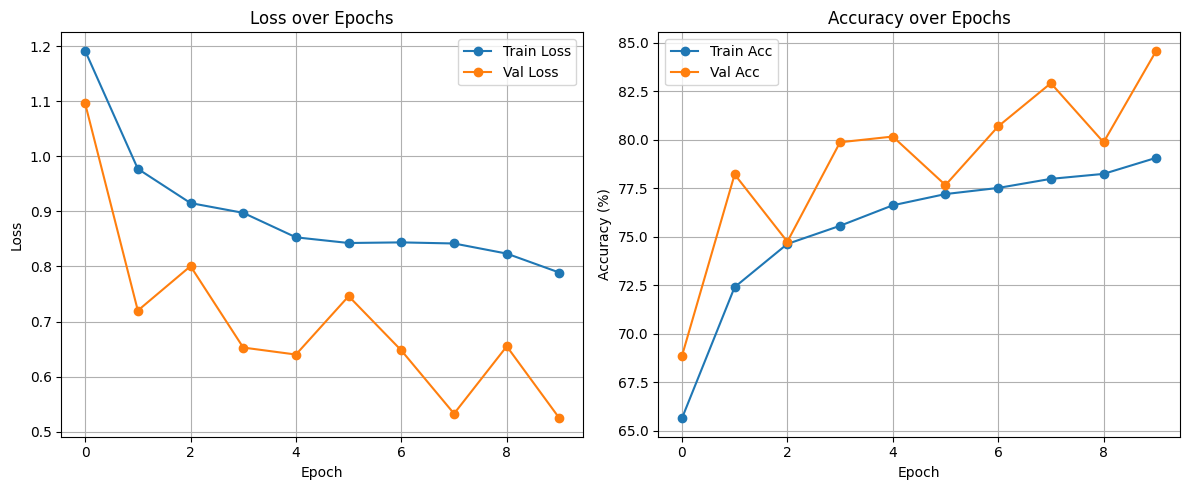

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'],   label='Val Loss',   marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'],   label='Val Acc',   marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()